In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import morethemes as mt
mt.set_theme('economist')
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
import fredapi as fp
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

In [99]:
df = pd.read_csv('S5ENGS.csv')
df.columns = [c.strip() for c in df.columns]
if 'S5ENRS Index - Last Price' in df.columns:
    df = df.rename(columns={'S5ENRS Index - Last Price': 'Price'})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
df['Price'] = df['Price'].astype(float)
df['ir_diff'] = df['Price'].pct_change()
df = df.dropna().copy()
df.head()


,Price,ir_diff
Date,,
1989-09-12,83.837,0.010474
1989-09-13,83.164,-0.008027
1989-09-14,82.196,-0.011640
1989-09-15,82.671,0.005779
1989-09-18,83.409,0.008927


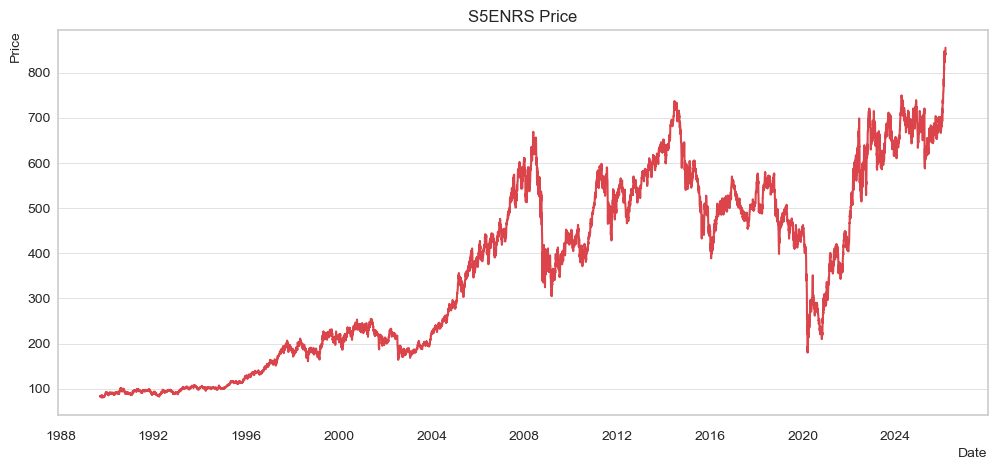

In [100]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Price'])
plt.title('S5ENRS Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()


In [101]:
def generate_signals(df, k, z, std_window=252, min_periods=20):
    df = df.copy()
    df['Filter'] = df['ir_diff'].ewm(alpha=k, adjust=False).mean()
    df['Filter Error'] = df['ir_diff'] - df['Filter']
    df['std'] = df['Filter Error'].rolling(window=int(std_window), min_periods=min_periods).std()
    df['Upper'] = df['Filter'] + z * df['std']
    df['Lower'] = df['Filter'] - z * df['std']
    df['signal'] = np.where(df['Filter Error'].abs() > z * df['std'], 1, np.nan) * np.sign(df['Filter Error'])
    df['signal'] = df['signal'].ffill().fillna(0)
    return df


def returns_generate(df):
    data = df.copy()
    data['returns'] = data['Price'].pct_change()
    data['strat_returns'] = data['signal'].shift() * data['returns']
    data['cum_strat'] = (1 + data['strat_returns'].fillna(0)).cumprod() - 1
    data['cum_bh'] = (1 + data['returns'].fillna(0)).cumprod() - 1
    return data


In [102]:
n = len(df)
split = int(np.floor(0.7 * n))
train = df.iloc[:split].copy()
test = df.iloc[split:].copy()
k_values = np.linspace(0.005, 0.99, 25)
z_values = np.linspace(0.1, 3.0, 25)
results = []
def annualized_sharpe_from_returns(r):
    r = r.dropna()
    if r.empty or r.std() == 0:
        return np.nan
    return (r.mean() / r.std()) * np.sqrt(252)

for k in k_values:
    for z in z_values:
        train_tmp = generate_signals(train, k, z, std_window=252, min_periods=20)
        perf_train = returns_generate(train_tmp)
        train_sharpe = annualized_sharpe_from_returns(perf_train['strat_returns'].fillna(0))
        train_final_return = perf_train['cum_strat'].iloc[-1] * 100
        results.append((k, z, train_final_return, train_sharpe))

results_df = pd.DataFrame(results, columns=['k','z','Rate of Return (%)','Training Sharpe']).sort_values('Training Sharpe', ascending=False).reset_index(drop=True)
best_row = results_df.loc[0]
best_k, best_z = best_row['k'], best_row['z']
print(f"Best (k,z) from training: k={best_k:.6f}, z={best_z:.6f} (Training Sharpe={best_row['Training Sharpe']:.6f})")
test_signals = generate_signals(test, best_k, best_z, std_window=252, min_periods=20)
perf_test = returns_generate(test_signals)
test_sharpe = annualized_sharpe_from_returns(perf_test['strat_returns'].fillna(0))
test_cum_return_pct = perf_test['cum_strat'].iloc[-1] * 100
print(f"Training Sharpe: {best_row['Training Sharpe']:.6f}")
print(f"Test Sharpe: {test_sharpe:.6f}")
print(f"Test Cumulative Return (pct): {test_cum_return_pct:.6f}")
results_df.head()


Best (k,z) from training: k=0.784792, z=3.000000 (Training Sharpe=0.257594)
Training Sharpe: 0.257594
Test Sharpe: 0.346156
Test Cumulative Return (pct): 89.778942


,k,z,Rate of Return (%),Training Sharpe
0,0.784792,3.000000,131.202215,0.257594
1,0.825833,3.000000,131.202215,0.257594
2,0.415417,1.187500,118.678938,0.248232
3,0.948958,2.395833,99.302099,0.232697
4,0.620625,1.429167,88.549004,0.223427


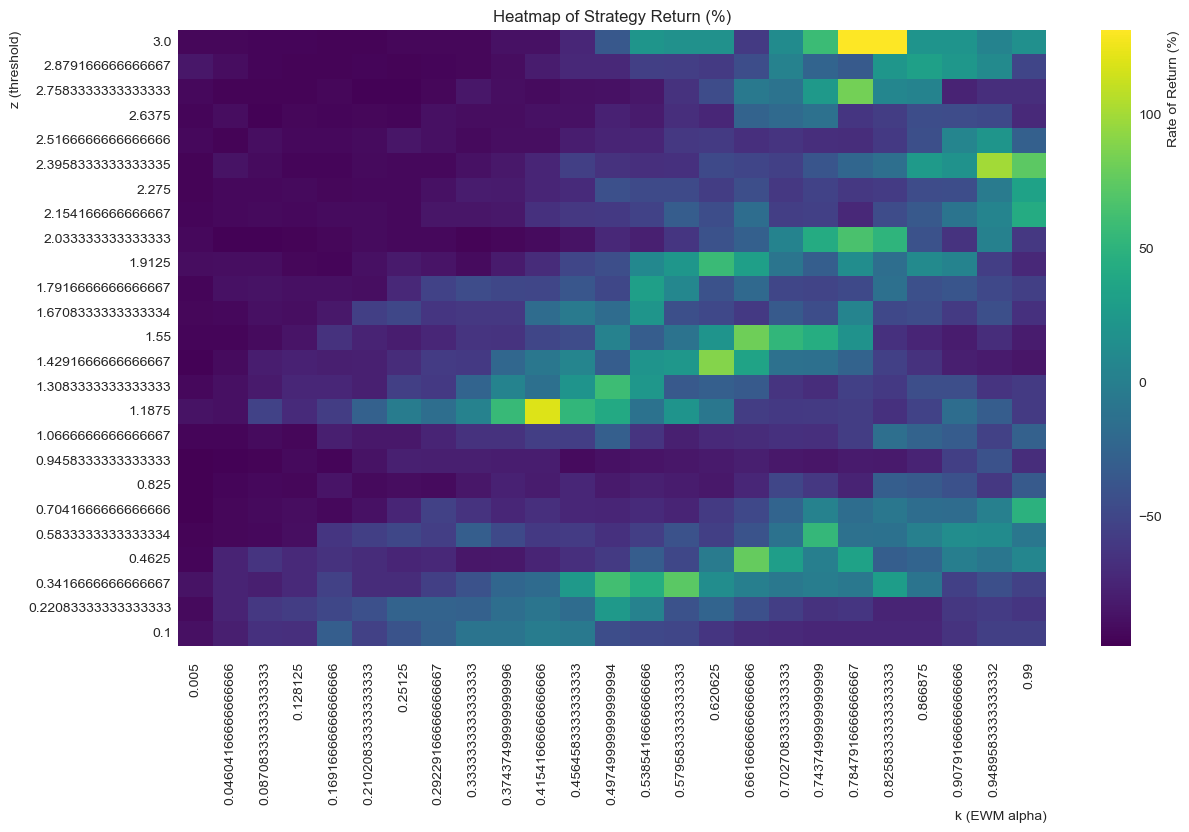

In [103]:
hm = results_df.pivot(index='z', columns='k', values='Rate of Return (%)')
plt.figure(figsize=(14,8))
sns.heatmap(hm, cmap='viridis', cbar_kws={'label':'Rate of Return (%)'})
plt.title('Heatmap of Strategy Return (%)')
plt.xlabel('k (EWM alpha)')
plt.ylabel('z (threshold)')
plt.gca().invert_yaxis()
plt.show()


Best k (training): 0.784792, Best z (training): 3.000000


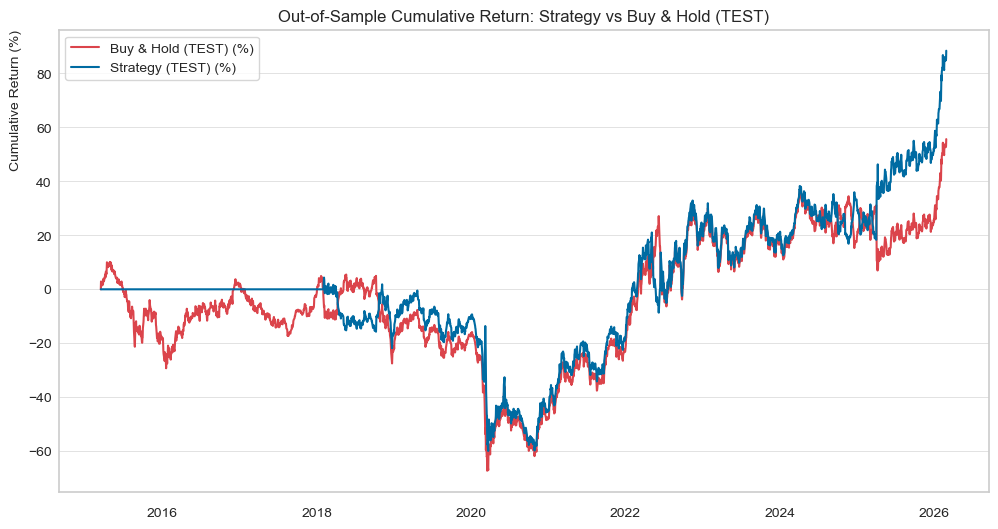

Out-of-Sample Final Strategy Return (pct): 88.43425900320894
Out-of-Sample Final Buy & Hold Return (pct): 55.66478071229377


,Price,ir_diff,Filter,Filter Error,std,Upper,Lower,signal,strat_returns,cum_strat
Date,,,,,,,,,,
2026-02-23,843.325,0.006012,0.003877,0.002135,0.004379,0.017014,-0.009260,1.0,0.006012,0.858386
2026-02-24,842.362,-0.001142,-0.000062,-0.001080,0.004362,0.013024,-0.013148,1.0,-0.001142,0.856264
2026-02-25,838.838,-0.004183,-0.003296,-0.000887,0.004358,0.009778,-0.016371,1.0,-0.004183,0.848498
2026-02-26,840.984,0.002558,0.001298,0.001260,0.004355,0.014364,-0.011768,1.0,0.002558,0.853227
2026-02-27,855.104,0.016790,0.013456,0.003334,0.004359,0.026534,0.000378,1.0,0.016790,0.884343


In [104]:
best_k, best_z = results_df.loc[0, ['k', 'z']]
print(f'Best k (training): {best_k:.6f}, Best z (training): {best_z:.6f}')
std_window = 252
df_signals = generate_signals(test, best_k, best_z, std_window=std_window, min_periods=std_window)
perf = returns_generate(df_signals)
plt.figure(figsize=(12,6))
plt.plot(perf.index, perf['cum_bh']*100, label='Buy & Hold (TEST) (%)')
plt.plot(perf.index, perf['cum_strat']*100, label='Strategy (TEST) (%)')
plt.title('Out-of-Sample Cumulative Return: Strategy vs Buy & Hold (TEST)')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.show()

print('Out-of-Sample Final Strategy Return (pct):', perf['cum_strat'].iloc[-1]*100)
print('Out-of-Sample Final Buy & Hold Return (pct):', perf['cum_bh'].iloc[-1]*100)

perf[['Price','ir_diff','Filter','Filter Error','std','Upper','Lower','signal','strat_returns','cum_strat']].tail()


In [105]:
n_train = len(train)
n_test = len(test)
perf_train = returns_generate(generate_signals(train, best_k, best_z, std_window=252, min_periods=20))
if 'rf' in globals():
    rf_daily_train = (rf / 252.0).reindex(perf_train.index).fillna(method='ffill').fillna(0).squeeze()
else:
    rf_daily_train = pd.Series(0.0, index=perf_train.index)
strat_excess_train = perf_train['strat_returns'].fillna(0) - rf_daily_train
train_sharpe = (strat_excess_train.mean() / strat_excess_train.std()) * np.sqrt(252) if strat_excess_train.std() != 0 else np.nan
if 'perf' in globals():
    perf_test = perf.copy()
else:
    perf_test = returns_generate(generate_signals(test, best_k, best_z, std_window=252, min_periods=252))
if 'rf' in globals():
    rf_daily_test = (rf / 252.0).reindex(perf_test.index).fillna(method='ffill').fillna(0).squeeze()
else:
    rf_daily_test = pd.Series(0.0, index=perf_test.index)
strat_excess_test = perf_test['strat_returns'].fillna(0) - rf_daily_test
test_sharpe = (strat_excess_test.mean() / strat_excess_test.std()) * np.sqrt(252) if strat_excess_test.std() != 0 else np.nan
test_cum_return = perf_test['cum_strat'].iloc[-1]
report = pd.DataFrame({
    'training_observations': [n_train],
    'test_observations': [n_test],
    'best_k': [best_k],
    'best_z': [best_z],
    'training_sharpe': [train_sharpe],
    'test_sharpe': [test_sharpe],
    'test_cumulative_return': [test_cum_return]
})
from IPython.display import display
display(report.T.rename(columns={0:'value'}))


,value
training_observations,6428.000000
test_observations,2755.000000
best_k,0.784792
best_z,3.000000
training_sharpe,0.112800
test_sharpe,0.268043
test_cumulative_return,0.884343


## Performance Metrics: Sharpe, Sortino, Max Drawdown, etc.

We'll load the S&P 500 price series and the 1-year Treasury (risk-free) and compute standard performance metrics for both the strategy and buy-and-hold.

,Strategy,Buy & Hold
Annualized Return,0.059666,0.041309
Annualized Vol,0.272347,0.292998
Sharpe,0.268043,0.211136
Sortino,0.023338,0.017487
Max Drawdown,-0.615971,-0.702606


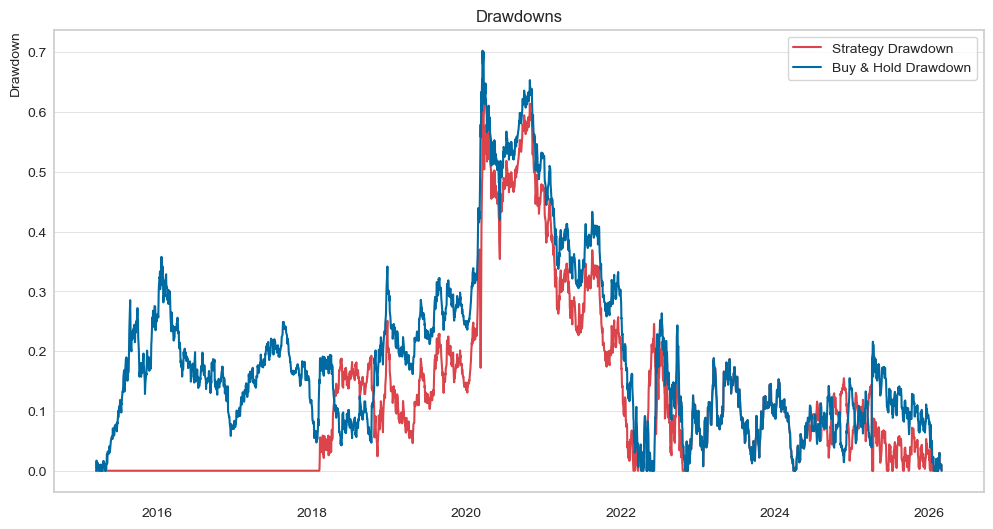

In [106]:
import os
sp_path = os.path.join('SP 500 and US Treasury', 'SP500 Price.csv')
rf_path = os.path.join('SP 500 and US Treasury', 'H15T1Y.csv')
sp = pd.read_csv(sp_path, header=0)
sp = sp.dropna(axis=1, how='all')
price_col = None
for c in sp.columns[1:]:
    sp[c] = pd.to_numeric(sp[c], errors='coerce')
    if pd.api.types.is_numeric_dtype(sp[c]):
        price_col = c
        break
if price_col is None:
    raise ValueError('Could not find numeric price column in SP500 Price CSV')
sp = sp.rename(columns={price_col: 'SP_Price'})
sp['Date'] = pd.to_datetime(sp['Date'], dayfirst=True, errors='coerce')
sp = sp.dropna(subset=['Date']).sort_values('Date').set_index('Date')
sp['SP_Price'] = sp['SP_Price'].astype(float)
rf = pd.read_csv(rf_path)
rf.columns = [c.strip() for c in rf.columns]
if 'Last Price' in rf.columns:
    rf = rf.rename(columns={'Last Price':'T1Y'})
rf['Date'] = pd.to_datetime(rf['Date'], dayfirst=True, errors='coerce')
rf = rf.dropna(subset=['Date']).sort_values('Date').set_index('Date')
rf['T1Y'] = pd.to_numeric(rf['T1Y'], errors='coerce')
rf = rf['T1Y'] / 100.0
if 'perf' not in globals():
    try:
        best_k, best_z = results_df.loc[0, ['k','z']]
        df_signals = generate_signals(df, best_k, best_z, std_window=252, min_periods=252)
        perf = returns_generate(df_signals)
    except Exception as e:
        raise RuntimeError('perf dataframe not found and could not recompute: ' + str(e))
rf_daily = (rf / 252.0).reindex(perf.index).fillna(method='ffill').fillna(0)
rf_daily = rf_daily.squeeze()
strat_r = perf['strat_returns'].fillna(0)
bh_r = perf['returns'].fillna(0)
def annualized_return(r):
    r = r.dropna()
    if r.empty:
        return np.nan
    compounded = (1 + r).prod()
    n = r.shape[0]
    return compounded ** (252.0 / n) - 1
def annualized_vol(r):
    return r.std() * np.sqrt(252)
def sharpe_ratio(r, rf_s):
    excess = r - rf_s
    return (excess.mean() / excess.std()) * np.sqrt(252) if excess.std() != 0 else np.nan
def sortino_ratio(r, rf_s, required_return=0.0):
    excess = r - rf_s - required_return
    downside = excess[excess < 0]
    if downside.empty:
        return np.nan
    dd = downside.std() * np.sqrt(252)
    return (excess.mean() * np.sqrt(252)) / dd if dd != 0 else np.nan
def max_drawdown(cum_returns):
    wealth = (1 + cum_returns).fillna(method='ffill')
    peak = wealth.cummax()
    drawdown = (wealth - peak) / peak
    return drawdown.min()
metrics = {}
metrics['Strategy Annualized Return'] = annualized_return(strat_r)
metrics['Strategy Annualized Vol'] = annualized_vol(strat_r)
metrics['Strategy Sharpe'] = sharpe_ratio(strat_r, rf_daily)
metrics['Strategy Sortino'] = sortino_ratio(strat_r, rf_daily)
metrics['Strategy Max Drawdown'] = max_drawdown(perf['cum_strat'])
metrics['BH Annualized Return'] = annualized_return(bh_r)
metrics['BH Annualized Vol'] = annualized_vol(bh_r)
metrics['BH Sharpe'] = sharpe_ratio(bh_r, rf_daily)
metrics['BH Sortino'] = sortino_ratio(bh_r, rf_daily)
metrics['BH Max Drawdown'] = max_drawdown(perf['cum_bh'])
import pandas as _pd
from IPython.display import display
metrics_ser = _pd.Series(metrics)
strat_metrics = {k.replace('Strategy ', ''): v for k, v in metrics.items() if k.startswith('Strategy ')},
bh_metrics = {k.replace('BH ', ''): v for k, v in metrics.items() if k.startswith('BH ')},
if isinstance(strat_metrics, tuple):
    strat_metrics = strat_metrics[0]
if isinstance(bh_metrics, tuple):
    bh_metrics = bh_metrics[0]
table = _pd.DataFrame({'Strategy': _pd.Series(strat_metrics), 'Buy & Hold': _pd.Series(bh_metrics)})
order = ['Annualized Return','Annualized Vol','Sharpe','Sortino','Max Drawdown']
table = table.reindex(order)
display(table.style.format('{:.6f}'))
table.round(6)
plt.figure(figsize=(12,6))
dd_strat = ((1+perf['cum_strat']).cummax() - (1+perf['cum_strat'])) / (1+perf['cum_strat']).cummax()
dd_bh = ((1+perf['cum_bh']).cummax() - (1+perf['cum_bh'])) / (1+perf['cum_bh']).cummax()
plt.plot(dd_strat.index, dd_strat, label='Strategy Drawdown')
plt.plot(dd_bh.index, dd_bh, label='Buy & Hold Drawdown')
plt.title('Drawdowns')
plt.ylabel('Drawdown')
plt.legend()
plt.show()